# Plan And Solve

from 2023

PS: 
先看看自己用到过哪些
- claude code的plan模式等等, 这些其实都是plan的思想

> 如果说 ReAct 像一个经验丰富的侦探，根据现场的蛛丝马迹（Observation）一步步推理，随时调整自己的调查方向；那么 Plan-and-Solve 则更像一位建筑师，在动工之前必须先绘制出完整的蓝图（Plan），然后严格按照蓝图来施工（Solve）。事实上我们现在用的很多大模型工具的Agent模式都融入了这种设计模式。

Plan And Solve 是一个建筑师, 先绘图, 再盖房子

ReAct 是一个顺其自然的高境界者

## 基本原理

将整个过程分为
- 规划阶段
- 执行阶段

用公式表示为

PS: 使用两个专有模型或者通用模型

首先,  $\boldsymbol{\pi_{\text{plan}}}$ 根据原始问题 $q$ 生成一个包含 $n$ 个步骤的计划 $P = (p_1,p_2,\dots,p_n)$：

$$
P = \pi_{\text{plan}}(q)
$$

然后, 执行器开始执行. 执行中, 给大模型的输入包括, 原始问题 $q$ 和, 规划模型生成的计划 $P$ , 还有之前每一步生成的结果

$$
s_i = \pi_{\text{solve}}\bigl(q,\, P,\, (s_1,\dots,s_{i-1})\bigr)
$$

其中, 按照计划执行可能会出现错误, 这个时候需要对 $P$ 进行调整, 具体见图

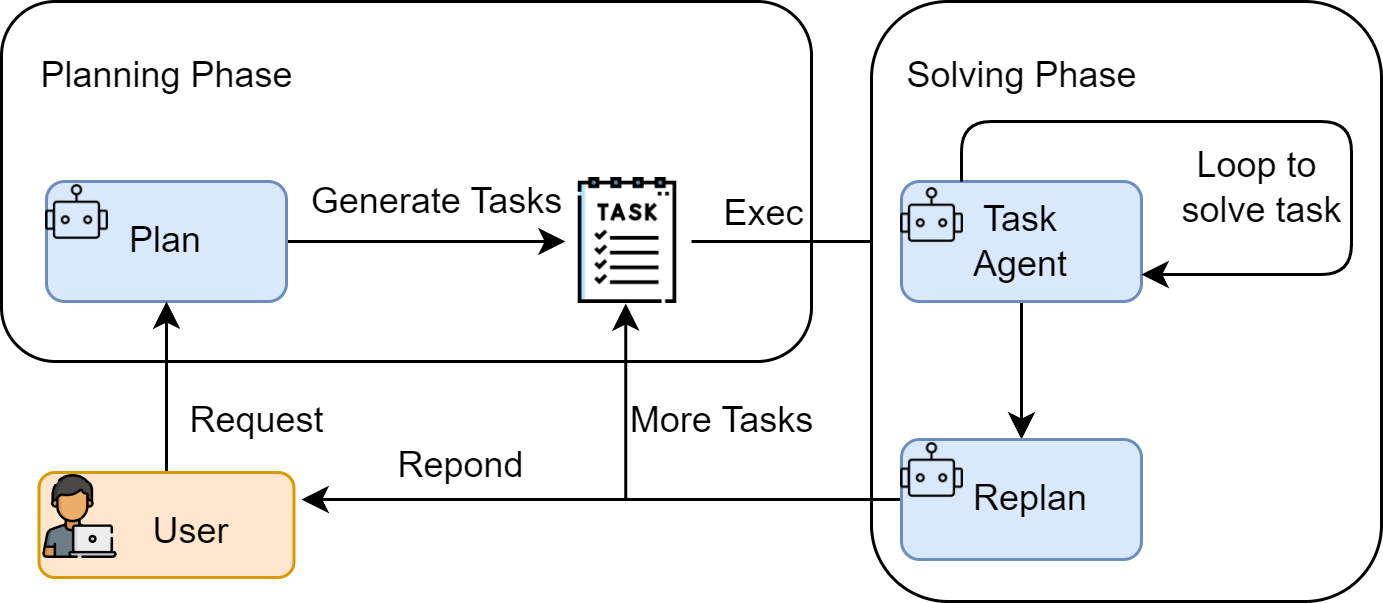

PS: 很明显, plan-and-solve范式特别适合结构化强(尤其是那些人们熟知的领域, 已经有了丰富的经验足以支撑规划)

## 规划阶段
## 执行阶段
没什么好写的, 很符合常识, 看代码吧


### 提示词构建

#### 设计协议

```json
{
  "thought": "...",
  "tasks": {
        "count": "<num_of_tasks>,
        "todo": [
            <task1>, <task2>, <task3>, ......
        ]
    },
}
```

In [1]:
from string import Template

PLANNER_PROMPT = Template("""
You are a “Task Planner (Planner)”. Given the user question $question, your ONLY job is to break it down into an executable, verifiable to-do list. Do NOT solve the problem and do NOT provide the final answer content—only the plan.

IMPORTANT: Do NOT add a separate final “verification” step at the end. The last step should directly produce the final deliverable/answer (no extra validate/check/verify stage).

[INPUT]
User question: $question

[STRICT OUTPUT REQUIREMENTS]
- Output ONLY valid, machine-parseable JSON. No extra text, no comments, no Markdown, no code fences.
- Follow this exact protocol and field names. Do NOT add, remove, or rename any fields:
{
  "thought": "...",
  "tasks": {
    "count": <num_of_tasks>,
    "todo": [ <task1>, <task2>, <task3>, ... ]
  }
}
- "count" MUST equal the length of "todo". "count" must be a number (no quotes).
- Each item in "todo" MUST be a single string, and each string MUST be one concise, actionable task that includes:
  an action + a concrete deliverable + a verification criterion.
  Recommended pattern:
  "Action verb...; Output: ...; Acceptance: ..."
- Order tasks by dependency so they can be executed top-to-bottom.
- If required information is missing: do NOT ask many questions; instead create early tasks to gather/confirm the minimum necessary info.
- Quality bar: prefer 4–8 tasks; avoid vague wording (e.g., “research”, “think about”, “optimize” without specifics). Every task must be immediately doable.

[THOUGHT FIELD RULE]
- "thought" must be 1–2 short sentences summarizing the high-level plan only (no step-by-step reasoning, no lengthy internal analysis).

Now produce ONLY the JSON that matches the protocol.
""")


In [2]:
%cd ../
!pwd

/Users/yqz/project/hello-agents
/Users/yqz/project/hello-agents


### 规划器构建

In [20]:
import json

class PlanAgent:
    def __init__(self, llm):
        self.client = llm

    def plan(self, question:str):
        prompt = PLANNER_PROMPT.substitute(
            question = question
        )
        messages = [
            {"role":"system", "content":prompt},
            {"role":"user", "content":question}
        ]

        response = self.client.generate(
            messages = messages
        )

        response_json = json.loads(response)

        tasks = response_json.get("tasks").get("todo")
        tasks_count = response_json.get("tasks").get("count")

        print(f"tasks count: {tasks_count}")
        print(f"the tasks: \n{tasks}\n")        

        return tasks

In [21]:
### 测试 PlanAgent

from mylib import MyLLM

my_llm = MyLLM()
my_plan_agent = PlanAgent(
    llm = my_llm
)

question="问题: 一个水果店周一卖出了15个苹果。周二卖出的苹果数量是周一的两倍。周三卖出的数量比周二少了5个。请问这三天总共卖出了多少个苹果？"

plan = my_plan_agent.plan(
    question=question
)

llm输入: 
[{'role': 'system', 'content': '\nYou are a “Task Planner (Planner)”. Given the user question 问题: 一个水果店周一卖出了15个苹果。周二卖出的苹果数量是周一的两倍。周三卖出的数量比周二少了5个。请问这三天总共卖出了多少个苹果？, your ONLY job is to break it down into an executable, verifiable to-do list. Do NOT solve the problem and do NOT provide the final answer content—only the plan.\n\nIMPORTANT: Do NOT add a separate final “verification” step at the end. The last step should directly produce the final deliverable/answer (no extra validate/check/verify stage).\n\n[INPUT]\nUser question: 问题: 一个水果店周一卖出了15个苹果。周二卖出的苹果数量是周一的两倍。周三卖出的数量比周二少了5个。请问这三天总共卖出了多少个苹果？\n\n[STRICT OUTPUT REQUIREMENTS]\n- Output ONLY valid, machine-parseable JSON. No extra text, no comments, no Markdown, no code fences.\n- Follow this exact protocol and field names. Do NOT add, remove, or rename any fields:\n{\n  "thought": "...",\n  "tasks": {\n    "count": <num_of_tasks>,\n    "todo": [ <task1>, <task2>, <task3>, ... ]\n  }\n}\n- "count" MUST equal the length of "todo". 

### 执行器

In [22]:
from string import Template

EXECUTOR_PROMPT = Template("""
You are a top-tier AI execution expert. Your task is to solve the problem step by step, strictly following the given plan.
You will receive the original question, the complete plan, and the steps/results completed so far.
Please focus only on solving the "current step" and output ONLY the final answer for that step, without any extra explanation or dialogue.

# Original question:
$question

# Full plan:
$plan

# Completed steps and results so far:
$history

# Current step:
$current_step

Please output ONLY the answer for the "current step":
""")

In [29]:
# 追求最小化实现demo, 无异常检查和执行错误额处理机制

from typing import List

class ExecuteAgent:
    def __init__(self, llm):
        self.client = llm
        self.history = []

    def execute(self, question: str, plan: List[str]):
        print(f"question: \n{question}\n")
        output = None
        for i, step in enumerate(plan):
            print('-'*10 + f"第{i+1}步" + '-'*10)
            print(f"executing: {step}")

            prompt = EXECUTOR_PROMPT.substitute(
                question = question,
                plan = plan,
                history = "\n".join(self.history),
                current_step = step
            )
            messages = [
                {"role": "user", "content": prompt}
            ]

            output = self.client.generate(
                messages
            )
            result = f"- step: {step}, result: {output}"
        
            self.history.append(result)
        print(f"final answer: {output}")
        return output

In [30]:
my_execute = ExecuteAgent(
    llm = my_llm
)

my_execute.execute(
    question=question,
    plan=plan
)

question: 
A fruit store sold 15 apples on Monday. The number of apples sold on Tuesday was twice that on Monday. The number sold on Wednesday was 5 less than that on Tuesday. How many apples were sold in total over these three days?

----------第1步----------
executing: Calculate Tuesday's apple sales as twice Monday's sales; Output: integer number of apples sold on Tuesday; Acceptance: equals 2 × 15
llm输入: 
[{'role': 'user', 'content': '\nYou are a top-tier AI execution expert. Your task is to solve the problem step by step, strictly following the given plan.\nYou will receive the original question, the complete plan, and the steps/results completed so far.\nPlease focus only on solving the "current step" and output ONLY the final answer for that step, without any extra explanation or dialogue.\n\n# Original question:\nA fruit store sold 15 apples on Monday. The number of apples sold on Tuesday was twice that on Monday. The number sold on Wednesday was 5 less than that on Tuesday. How 

'70'

### 组合执行

In [31]:
class PlanAndSolveAgent:
    def __init__(self, llm):
        self.plan_agent = PlanAgent(llm=llm)
        self.execute_agent = ExecuteAgent(llm=llm)

    def run(self, question):
        # 制定计划
        print("=" * 60)
        print("Planning")
        print("=" * 60)
        plan = self.plan_agent.plan(
            question = question
        )

        # 开始执行
        print("=" * 60)
        print("Executing")
        print("=" * 60)
        result = self.execute_agent.execute(
            question=question,
            plan=plan
        )

        # 输出
        print("=" * 60)
        print(f"final_result: {result}")
        print("=" * 60)

In [32]:
question = "A fruit store sold 15 apples on Monday. The number of apples sold on Tuesday was twice that on Monday. The number sold on Wednesday was 5 less than that on Tuesday. How many apples were sold in total over these three days?"

In [33]:
from mylib import MyLLM

my_llm = MyLLM()

In [34]:
my_plan_and_solve_agent = PlanAndSolveAgent(
    llm=my_llm
)

my_plan_and_solve_agent.run(
    question=question
)

Planning
llm输入: 
[{'role': 'system', 'content': '\nYou are a “Task Planner (Planner)”. Given the user question A fruit store sold 15 apples on Monday. The number of apples sold on Tuesday was twice that on Monday. The number sold on Wednesday was 5 less than that on Tuesday. How many apples were sold in total over these three days?, your ONLY job is to break it down into an executable, verifiable to-do list. Do NOT solve the problem and do NOT provide the final answer content—only the plan.\n\nIMPORTANT: Do NOT add a separate final “verification” step at the end. The last step should directly produce the final deliverable/answer (no extra validate/check/verify stage).\n\n[INPUT]\nUser question: A fruit store sold 15 apples on Monday. The number of apples sold on Tuesday was twice that on Monday. The number sold on Wednesday was 5 less than that on Tuesday. How many apples were sold in total over these three days?\n\n[STRICT OUTPUT REQUIREMENTS]\n- Output ONLY valid, machine-parseable J